**Student Declaration**

I [Didem Demirci, 48670871] declare that this is my own work and that

I only used CHATGPT for grammar while preparing this assessment

This work consists of 3 sections

Section 1: Data Cleansing

Section 2: Analysis

Section 3:Recommendations


**Section 1: Data Cleansing**

In this section;

1.  Clean the data
2. Find and fix missing values if any
3. Fix duplicates if any
4. Find and fix wrong entries if any
5. Use Histogram and Boxplot
6. Fix outliers if any
7. Fix skewness if any

The analyses will include:

**Clean the data**

In [4]:
import pandas as pd
import numpy as np
shop = pd.read_csv('customer_shopping_data.csv')

In the first step of my project, I loaded the dataset using the pandas and numpy libraries.

In [6]:
shop.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,8/05/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,11/09/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,5/16/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,10/24/2021,Kanyon


After loading the dataset, I examined the first few lines to better understand the data structure.

In [8]:
shop.tail()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
99456,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,9/21/2022,Kanyon
99457,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,9/22/2021,Forum Istanbul
99458,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,3/28/2021,Metrocity
99459,I702964,C800631,Male,56,Technology,4,4200.00,Cash,3/16/2021,Istinye Park
99460,I232867,C273973,Female,36,Souvenir,3,35.19,Credit Card,10/15/2022,Mall of Istanbul


In addition to the data at the beginning of the dataset, I also examined the data at the end of the dataset to try to understand the data structure more comprehensively.

In [13]:
shop.shape

(99461, 10)

I used the shape function to see the dimensions of the dataset, i.e. the number of rows and columns.

The dataset includes 10 attributes and 99461 observations.

In [16]:
shop.nunique()

invoice_no        99458
customer_id       99457
gender                3
age                  53
category             15
quantity              5
price                41
payment_method        6
invoice_date        812
shopping_mall        11
dtype: int64

I ran this code to see how many different values each columna had, so I could make myself an idea between what variables ara categorical and which are numeric, and if there is any mistake in the dataset.

In [19]:
shop.describe()

,age,quantity,price
count,99461.000000,99461.000000,99459.000000
mean,43.427796,3.003398,689.253423
std,14.990849,1.413029,941.195107
min,18.000000,1.000000,0.990000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,99.000000,5.000000,5250.000000


I used this code to have a quick overview of the general statistics of numeric columns in my dataset. The shop.describe() command gives information such as mean, standard deviations, minimum, and maximum values of columns. This helped me get an idea about how the data was distributed and if there were any outliers.

In [22]:
shop.columns

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall'],
      dtype='object')

To help you understand what information is included in the dataset, I have listed the names of all the columns included in the dataset.

In [26]:
shop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99461 entries, 0 to 99460
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99461 non-null  object 
 1   customer_id     99461 non-null  object 
 2   gender          99461 non-null  object 
 3   age             99461 non-null  int64  
 4   category        99461 non-null  object 
 5   quantity        99461 non-null  int64  
 6   price           99459 non-null  float64
 7   payment_method  99460 non-null  object 
 8   invoice_date    99461 non-null  object 
 9   shopping_mall   99461 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


Being able to know the data types of the columns in the dataset, the number of missing data, and the memory usage, I could notice the overall structure and nature of the dataset.

6 price 99459 non-null float 64 7 payment_method 99460 non-null object

**Handling Missing Values**

In [31]:
print(shop[shop['payment_method'].isna()])

    invoice_no customer_id gender  age  category  quantity    price  \
298    I215906     C296862   Male   21  Clothing         4  1200.32   

    payment_method invoice_date     shopping_mall  
298            NaN    8/13/2021  Mall of Istanbul  


The following code identified for me the rows where no payment method was given. I would like to further process these rows to get an exact view of how missing data impacts your analysis.

In [34]:
print(shop[shop['price'].isna()])

    invoice_no customer_id  gender  age   category  quantity  price  \
64     I218590     C224743  Female   29  Cosmetics         4    NaN   
419    I177957     C653357    Male   65   Clothing         4    NaN   

    payment_method invoice_date shopping_mall  
64      Debit Card    5/09/2022  Metropol AVM  
419           Cash    7/04/2021   Cevahir AVM  


I used this code to see in which records information was missing on the price. This information allowed me to see which records these were.

In [37]:
shop.dropna(subset=['price'], inplace= True)

This code removed the missing rows that are to do with price information in my dataset, thereby enriching it.

In [40]:
#Filter data for cosmetics category
cosmetics_data = shop[shop['category'] == 'Cosmetics']

#Calculate mean spend by gender
mean_spend_female = cosmetics_data[cosmetics_data['gender'] == 'Female']['price'].mean()
mean_spend_male = cosmetics_data[cosmetics_data['gender'] == 'Male']['price'].mean()

print(f'Mean spend by females in Cosmetics : ${mean_spend_female:.2f}')
print(f'Mean spend by males in Cosmetics : ${mean_spend_male:.2f}')

Mean spend by females in Cosmetics : $122.20
Mean spend by males in Cosmetics : $122.81


I used the given code to find the average spend by female customers who fall under the cosmetics category. This helped me get an idea of spending behavior based on gender.

I have calculated the average spend of male customers in the cosmetics category using this code. These results are compared with the average spend by female customers to find out the differences in spending between genders.

**Handling Duplicates and Format**

In [45]:
#Check invoice number and duplicates
duplicates= shop[shop.duplicated(subset=['invoice_no', 'customer_id'], keep=False)]
print(duplicates)

      invoice_no customer_id  gender  age         category  quantity    price  \
236      I218385     C290280  Female   51             Toys         1    35.84   
237      I218385     C290280  Female   51             Toys         1    35.84   
249      I120948     C340089  Female   54             Shoe         4  2400.68   
250      I120948     C340089  Female   54            Shoes         4  2400.68   
99389    I170876     C320288    Male   40             Food         3    15.69   
99390    I170876     C320288    Male   40  Food & Beverage         3    15.69   

      payment_method invoice_date     shopping_mall  
236             Cash        44761         Metrocity  
237             Cash    7/19/2022         Metrocity  
249       Debit Card        44416  Mall of Istanbul  
250       Debit Card    8/08/2021  Mall of Istanbul  
99389           Cash        44787         Metrocity  
99390           Cash    8/14/2022         Metrocity  


Using this code, I was able to filter the records that had the same invoice number and customer ID. Definitely, a necessity in being able to identify such records is due to the fact that one of the primary impacts of an occurrence of duplicates is errors in data analysis.

In [48]:
shop.drop(shop.iloc[[237,249,99389]].index, inplace=True)

It went ahead to help me remove some duplicate records within the dataset using this code. This made my dataset cleaner and more accurate

**Data Type Conversion**

In [52]:
unique_lengths = shop['invoice_date'].str.len().unique()
print(unique_lengths)


[ 9 10  5]


It returns character lengths of dates in column 'invoice_date'. This helped in finding out unique lengths and thus detecting the inconsistency of date format.

In [55]:
short_values=shop[shop['invoice_date'].str.len() < 6]
print(short_values)

      invoice_no customer_id  gender  age         category  quantity    price  \
13       I179802     C312861    Male   25           Clothi         2   600.16   
30       I161949     C159164  Female   66              Toy         3   107.52   
49       I304265     C653385  Female   22             Boks         5    75.75   
112      I299820     C820515  Female   22             Boks         3    45.45   
236      I218385     C290280  Female   51             Toys         1    35.84   
249      I120948     C340089  Female   54             Shoe         4  2400.68   
353      I508712     C216619  Female   64             Toys         3   107.52   
53518    I226929     C185726  Female   43         Cosmetic         3   121.98   
53519    I303174     C305002  Female   20             Tech         1  1050.00   
53539    I291878     C119087     Mal   49             Toys         3   107.52   
53606    I565111     C223892  Female   99            Books         1     0.99   
76666    I263423     C924731

I set up in this code a filter for dates with a character length less than 6 in the column invoice_date and displayed those values. It was done to detect possible wrong or missing data in the date format.

In [58]:
import pandas as pd

def convert_date(x):
    if len(str(x)) == 5: 
        serial_date = int(x)
        date = pd.to_datetime(pd.Timedelta(days=serial_date - 1) + pd.to_datetime('1899-12-30'))
        return date.strftime('%d/%m/%Y')  
    else:
        return str(x) 


shop['invoice_date'] = shop['invoice_date'].apply(convert_date)

This code has changed the date data into a standard format of datetime. This was particularly necessary to perform time series analysis.

In [61]:
#convert to date time
#df['date'] = pd.to_datetime(df['date', errors=çoerce')
shop['invoice_date'] = pd.to_datetime(shop['invoice_date'], format= 'mixed',errors= 'coerce')
#shop['invoice_date'] = pd.to_datetime(shop['invoice_date'], format= 'mixed')

With the code above, I converted the dates in the 'invoice_date' column into a different format. I did provide the errors='coerce' so that the wrongly interpreted and invalidly interpreted date values would be replaced with NaT.

In [64]:
shop_sorted = shop.sort_values(by='invoice_date', ascending=False)
print(shop_sorted.head())

      invoice_no customer_id  gender  age    category  quantity    price  \
53606    I565111     C223892  Female   99       Books         1     0.99   
19151    I110168     C233489    Male   64    Clothing         4  1200.32   
22102    I145971     C418514  Female   67    Clothing         2   600.16   
60922    I273565     C203014    Male   25    Clothing         5  1500.40   
10398    I230457     C141117  Female   18  Technology         2  2100.00   

      payment_method invoice_date     shopping_mall  
53606      ##error##   2023-11-01  Mall of Istanbul  
19151           Cash   2023-03-08  Mall of Istanbul  
22102           Cash   2023-03-08    Viaport Outlet  
60922     Debit Card   2023-03-08            Kanyon  
10398    Credit Card   2023-03-08  Mall of Istanbul  


I applied this code to sort the dataset by the invoice_date column in descending order (ascending=False) and then viewed the first five rows of the sorted dataset, ensuring that the data with the latest date was right at the top, which helped sort the dataset based on the date automatically.

In [67]:
shop.describe()

,age,quantity,price,invoice_date
count,99456.000000,99456.000000,99456.000000,99456
mean,43.427868,3.003388,689.215386,2022-02-04 02:53:07.355212544
min,18.000000,1.000000,0.990000,2021-01-01 00:00:00
25%,30.000000,2.000000,45.450000,2021-07-19 00:00:00
50%,43.000000,3.000000,203.300000,2022-02-05 00:00:00
75%,56.000000,4.000000,1200.320000,2022-08-22 00:00:00
max,99.000000,5.000000,5250.000000,2023-11-01 00:00:00
std,14.990856,1.413039,941.160502,NaN


In [69]:
shop.shape

(99456, 10)

In [71]:
# Check if invoice_no starts with 'I' and is followed by 6 digits
mask = shop['invoice_no'].str.match(r'^I\d{6}$')

# Check for unique invoice numbers
unique_mask = shop['invoice_no'].duplicated(keep=False)

# Combine the two conditions
invalid_invoice_no = shop[~mask | unique_mask]

print(invalid_invoice_no)

      invoice_no customer_id  gender  age         category  quantity  price  \
236      I218385     C290280  Female   51             Toys         1  35.84   
237      I218385     C290280  Female   51             Toys         1  35.84   
99389    I170876     C320288    Male   40             Food         3  15.69   
99390    I170876     C320288    Male   40  Food & Beverage         3  15.69   

      payment_method invoice_date shopping_mall  
236             Cash   2022-07-18     Metrocity  
237             Cash   2022-07-19     Metrocity  
99389           Cash   2022-08-13     Metrocity  
99390           Cash   2022-08-14     Metrocity  


I have been able to find out through this code that the invoice numbers did not start with 'I,' did not move with 6 digits, and duplicate the invoice_no column, now displaying invalid records.

In [74]:
pattern = r'^C\d{6}$'

#shop['customer_id_valid'] = shop['customer_id'].apply(lambda x: bool(pd.Series(str(x)) .str.match(pattern)))
shop['customer_id_valid'] = shop['customer_id'].astype(str).str.match(pattern).fillna(False).astype(bool)

# invalid customer id's
print(shop[~shop['customer_id_valid']])

      invoice_no customer_id  gender  age   category  quantity  price  \
99418    I166977     C2061##  Female   34  Cosmetics         5  203.3   

      payment_method invoice_date shopping_mall  customer_id_valid  
99418    Credit Card   2022-04-02        Kanyon              False  


I used this code to check whether the customer IDs in the column customer_id started with 'C' and were continued by 6 digits, and I displayed the wrong customer IDs.

In [77]:
print(shop[shop['invoice_no']=='I166977']) 

      invoice_no customer_id  gender  age   category  quantity  price  \
99418    I166977     C2061##  Female   34  Cosmetics         5  203.3   

      payment_method invoice_date shopping_mall  customer_id_valid  
99418    Credit Card   2022-04-02        Kanyon              False  


This code will filter and show rows that include 'I166977' in the column invoice_no. It was to check records for an invoice number in particular.

In [80]:
#print(shop[shop[customer_id'].str.startswith('C2061')])
#print(shop[shop[customer_id'].str.startswith('C2061'))&(shop['gender'] =='Female)])
print(shop[(shop['customer_id'].str.startswith('C2061'))&(shop['gender'] == 'Female') & (shop['age'] == 34)])

      invoice_no customer_id  gender  age   category  quantity  price  \
99418    I166977     C2061##  Female   34  Cosmetics         5  203.3   

      payment_method invoice_date shopping_mall  customer_id_valid  
99418    Credit Card   2022-04-02        Kanyon              False  


Using this code, I filtered to display the customer records where the column customer_id starts with 'C2061', gender is 'Female', and age is 34.

In [83]:
print(shop['category'].unique())

['Clothing' 'Shoes' 'Books' 'Cosmetics' 'Food & Beverage' 'Toys' 'Clothi'
 'Technology' 'Toy' 'Boks' 'Souvenir' 'Shoe' 'Cosmetic' 'Tech' 'Food']


The following code should return a list with the unique values ​​in the category column. I did this in order to see and have a look at the various categories within this dataset.

In [86]:
#Correct Misspelled names
cat_corrections = {'Clothi':'Clothing', 'Toy' :'Toys','Shoe':'Shoes','Boks':'Books', 'Cosmetic':'Cosmetics','Tech':'Technology','Food':'Food & Beverage', 
'Souvenir': 'Souvenirs'}

Using this code, I then created a dictionary of correction, with which the misspelled category names in the category column would then be matched with their correct alliteration form; that is, it would match 'Clothing' instead of 'Clothi' to correct the category names in the data set to be consistent throughout and correct.

In [89]:
#use replace to replace the previous values  with correct values

shop['category'] = shop['category'].replace(cat_corrections)

I used this code, which replaced misspellings in the values ​​of the category column by the right values ​​from my previously defined cat_corrections dictionary. This was done for the correction of inconsistencies in the dataset, thus refining the names of categories.

In [92]:
print(shop['category'].unique())

['Clothing' 'Shoes' 'Books' 'Cosmetics' 'Food & Beverage' 'Toys'
 'Technology' 'Souvenirs']


In [94]:
print(shop['shopping_mall'].unique())

['Kanyon' 'Forum Istanbul' 'Metrocity' 'Metropol AVM' 'Istinye Park'
 'Mall of Istanbul' 'Emaar Square Mall' 'Cevahir AVM' 'Viaport Outlet'
 'Zorlu Center' 'Mall Istanbul']


Using this code, I have listed the unique shopping mall names in the column shopping_mall. It was to show which shopping malls are present in the dataset.

In [97]:
print(shop['payment_method'].unique())  

['Credit Card' 'Debit Card' 'Cash' nan '##error##' 'Cash Cash'
 'CreditCard']


I used this code to list out the unique payment methods in the column payment_method. This was done to determine which payment methods were used in the dataset.

In [100]:
pmt_corrections = {'Cash Cash': 'Cash', 'CreditCard': 'Credit Card', '##error##': 'Cash', np.nan: 'Cash'}

I used this code to create a correction dictionary, pmt_corrections, to correct the misspellings or inconsistencies in the names of the payment methods appearing in the column payment_method. This dictionary shall be used for converting the misspelled or incorrect values ​​to their correct form. For example, 'Cash Cash' instead of 'Cash'.

In [103]:
shop['payment_method']=shop['payment_method'].replace(pmt_corrections)

In [105]:
print(shop['payment_method'].unique())   

['Credit Card' 'Debit Card' 'Cash']


Applying this code, I re-listed the corrected unique payment methods into the payment method column. This took a look at whether the corrections worked and found out what payment methods had been entered into the data set.

In [108]:
mean_price = shop.groupby(['category', 'payment_method'])['price'].mean()
print(mean_price)

category         payment_method
Books            Cash                45.610683
                 Credit Card         45.217748
                 Debit Card          46.016077
Clothing         Cash               903.618230
                 Credit Card        895.298974
                 Debit Card         905.466979
Cosmetics        Cash               121.425601
                 Credit Card        124.075484
                 Debit Card         121.835068
Food & Beverage  Cash                15.580446
                 Credit Card         15.731840
                 Debit Card          15.770078
Shoes            Cash              1809.900232
                 Credit Card       1810.645153
                 Debit Card        1796.024425
Souvenirs        Cash                34.410122
                 Credit Card         35.243017
                 Debit Card          35.339794
Technology       Cash              3157.046980
                 Credit Card       3186.558219
                 Debit Card 

I used this code to compute the average price for each combination of categories and payment methods, making a display of the results. This was undertaken to see how the average spend amounts were across different categories and payment methods.

In [111]:
print(shop[shop['payment_method'].isna()])

Empty DataFrame
Columns: [invoice_no, customer_id, gender, age, category, quantity, price, payment_method, invoice_date, shopping_mall, customer_id_valid]
Index: []


In [113]:
print(shop['gender'].unique())

['Female' 'Male' 'Mal']


Using this code, I listed unique values ​​in the column 'gender'. I did this just to see what kind of gender existed in the dataset.



In [116]:
shop['gender'] = shop['gender'].replace({'Mal': 'Male'})

Using this code, I have replaced the misspelled gender value as 'Mal' in the column for gender to 'Male'. This was done in order to rectify inconsistency in the gender data.

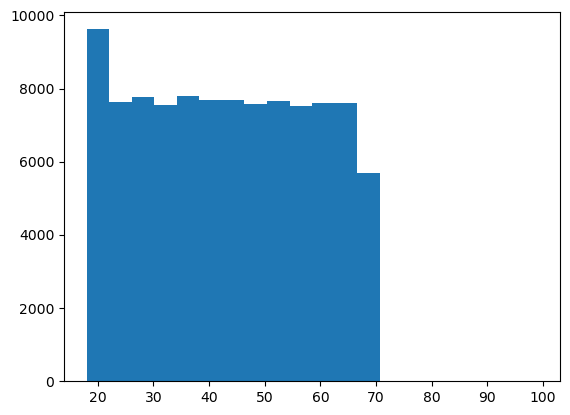

In [119]:
import matplotlib.pyplot as plt

plt.hist(shop['age'], bins=20)
plt.show()

Using this code, I created and plotted a histogram with 20 knuckles (bins) from data provided about customer money. The age data in the age column was binned to carry out a visual understanding of the distribution of customer age and accordingly learned how different age groups can be represented.

This histogram shows that the ages of the customers are very much spread out, which, in turn, means all age groups are equally represented. The age data is broken down into 20 ranges, all of whom have a comparable number of customers, thus showing an age-diverse customer base with no single age group dominating the market.

(array([6.386e+03, 6.420e+03, 6.462e+03, 6.484e+03, 6.345e+03, 6.513e+03,
        6.392e+03, 6.460e+03, 6.520e+03, 6.384e+03, 6.510e+03, 6.520e+03,
        6.508e+03, 6.339e+03, 6.536e+03, 2.676e+03, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([18628. , 18679.7, 18731.4, 18783.1, 18834.8, 18886.5, 18938.2,
        18989.9, 19041.6, 19093.3, 19145. , 19196.7, 19248.4, 19300.1,
        19351.8, 19403.5, 19455.2, 19506.9, 19558.6, 19610.3, 19662. ]),
 <BarContainer object of 20 artists>)

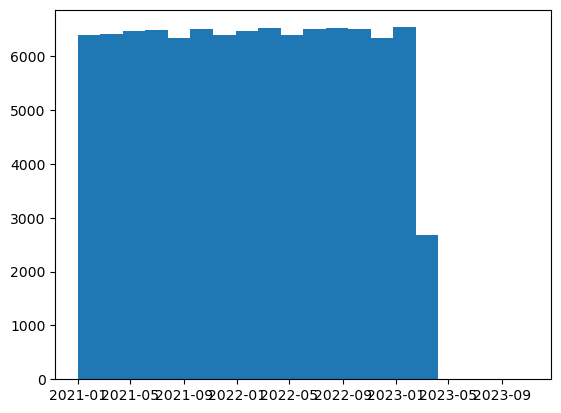

In [122]:
plt.hist(shop['invoice_date'],bins=20)

The following code constructed a histogram of the date data in the invoice_date column by dividing it into 20 bins.

This histogram illustrates the distribution of data in the invoice_date column and clearly identifies the periods in which the invoices were concentrated in 2021 and 2023. It can be seen that the concentration happened mainly in 2021 and early 2022, also in the middle of the year 2023.

In [127]:
#number of missing values in each columns
missing_values = shop.isnull().sum()
print(missing_values)

invoice_no           0
customer_id          0
gender               0
age                  0
category             0
quantity             0
price                0
payment_method       0
invoice_date         0
shopping_mall        0
customer_id_valid    0
dtype: int64


In [129]:
# percentage of missing values in the dataset
missing_percentage = shop.isnull().sum() / len(shop) * 100
print(missing_percentage)

invoice_no           0.0
customer_id          0.0
gender               0.0
age                  0.0
category             0.0
quantity             0.0
price                0.0
payment_method       0.0
invoice_date         0.0
shopping_mall        0.0
customer_id_valid    0.0
dtype: float64


With this code, I managed to calculate and return what percentage of the missing values in the dataset each column holds. This is in order to get an understanding of how common missing data was in the dataset.

**Dropping Missing Values**

In [133]:
shop.dropna(inplace=True)

I used this code and completely purged the dataset of rows with missing values. This was done so that missing data would not affect the analysis.

In [136]:
shop.dropna(axis=1, inplace=True)

In [138]:
print(shop.isnull().sum())

invoice_no           0
customer_id          0
gender               0
age                  0
category             0
quantity             0
price                0
payment_method       0
invoice_date         0
shopping_mall        0
customer_id_valid    0
dtype: int64


There are no missing values in our dataset.

In [141]:
# Fill missing values in the 'age' column with the median age
shop['age'] = shop['age'].fillna(shop['age'].median())

# Fill missing values in the 'payment_method' column with the most frequent value (mode)
shop['payment_method'] = shop['payment_method'].fillna(shop['payment_method'].mode()[0])

I used these codes to fill in missing values ​​in the column age with a median age and missing values ​​in column payment_method with the most used payment method mode. This was done to fill up missing data in a more meaningful way.

In [144]:
# Drop rows where any column has missing values
shop = shop.dropna()

In [146]:
# Check if there are any remaining missing values
print(shop.isna().sum())

invoice_no           0
customer_id          0
gender               0
age                  0
category             0
quantity             0
price                0
payment_method       0
invoice_date         0
shopping_mall        0
customer_id_valid    0
dtype: int64


In [148]:
import pandas as pd

# Load the data into a DataFrame
cleaned_shop = pd.read_csv('cleaned_customer_shopping_data.csv')

It loads data from the file called 'cleaned_customer_shopping_data.csv' into a DataFrame, cleaned_shop. It was important to do this because the cleaned dataset needs to be brought into pandas for analysis.

In [151]:
# Fill missing values in the 'price' column with the mean value
cleaned_shop['price'] = cleaned_shop['price'].fillna(cleaned_shop['price'].mean())

# Fill missing values in the 'payment_method' column with the most frequent value (mode)
cleaned_shop['payment_method'] = cleaned_shop['payment_method'].fillna(cleaned_shop['payment_method'].mode()[0])

These codes were used to fill in missing values ​​in the cleaned_shop dataset. The missing values ​​in the column price are filled with the average value, while the missing values ​​in the column of payment_method are filled with the most used one.

In [154]:
shop.shape

(99456, 11)

**Use Histogram and Boxplot**

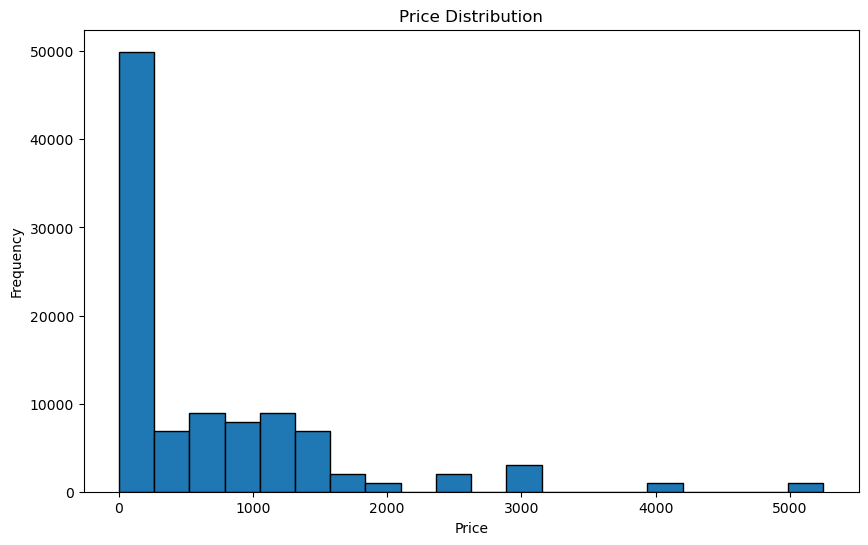

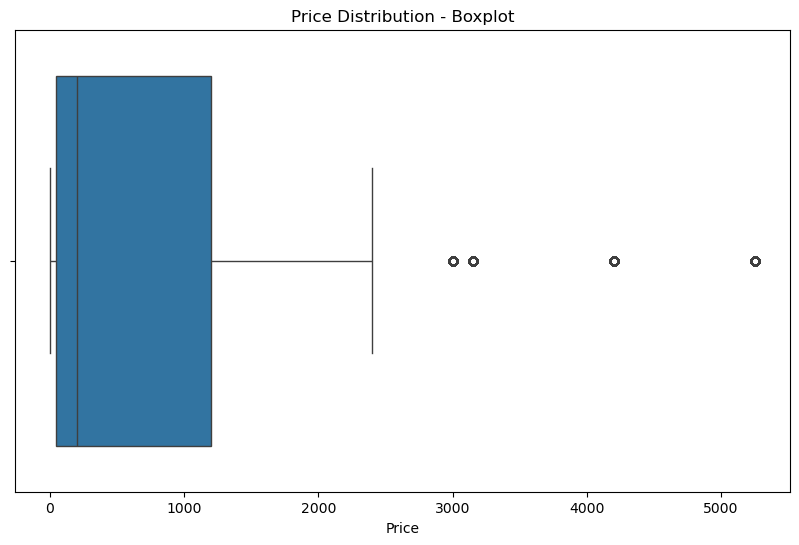

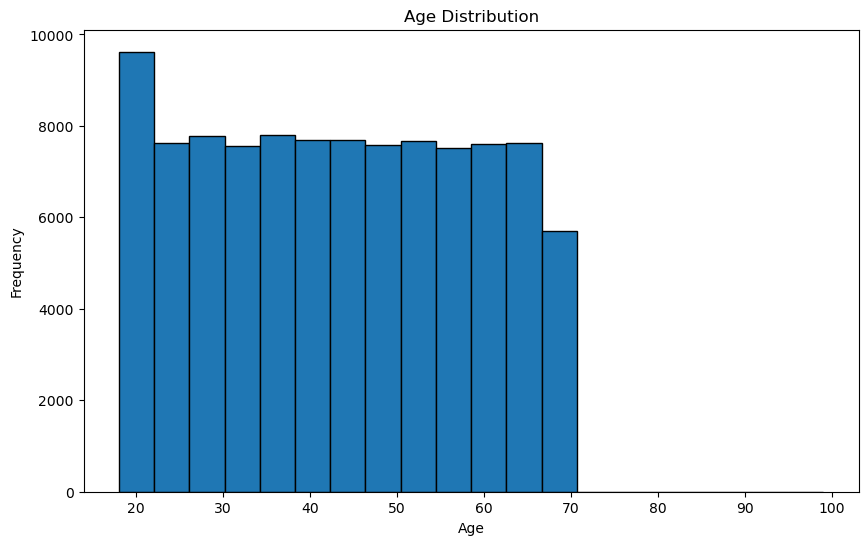

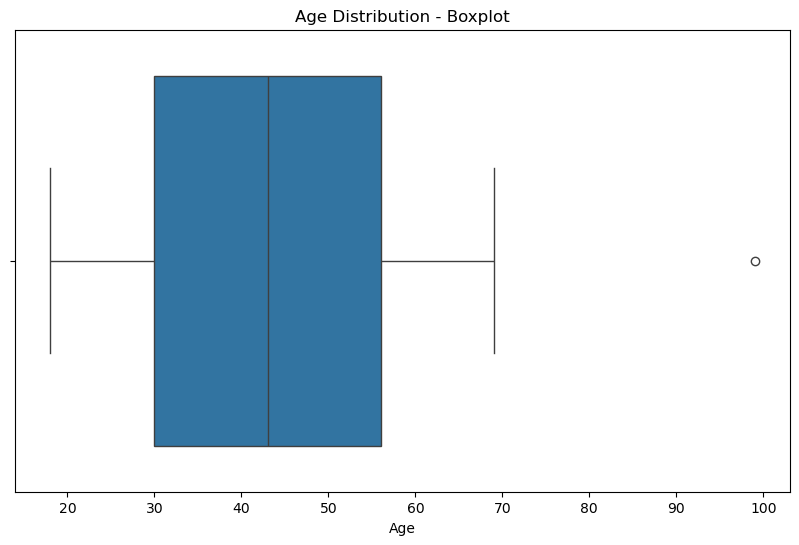

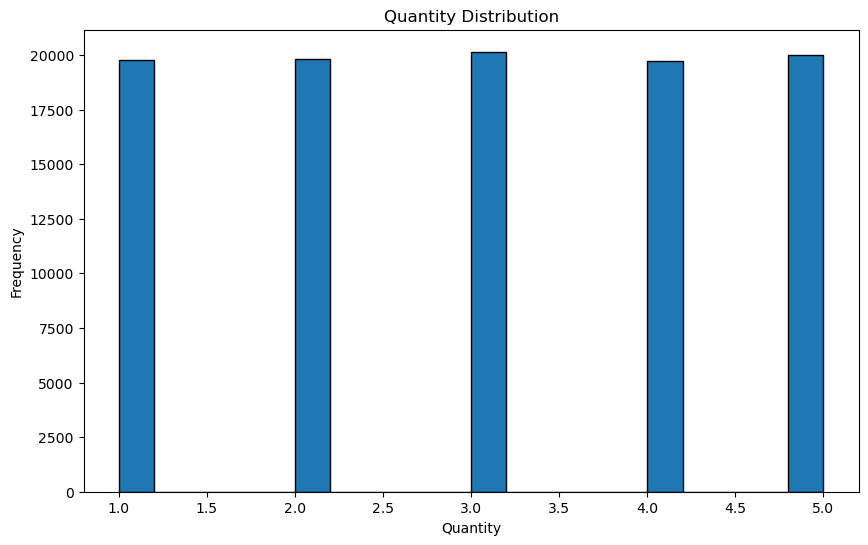

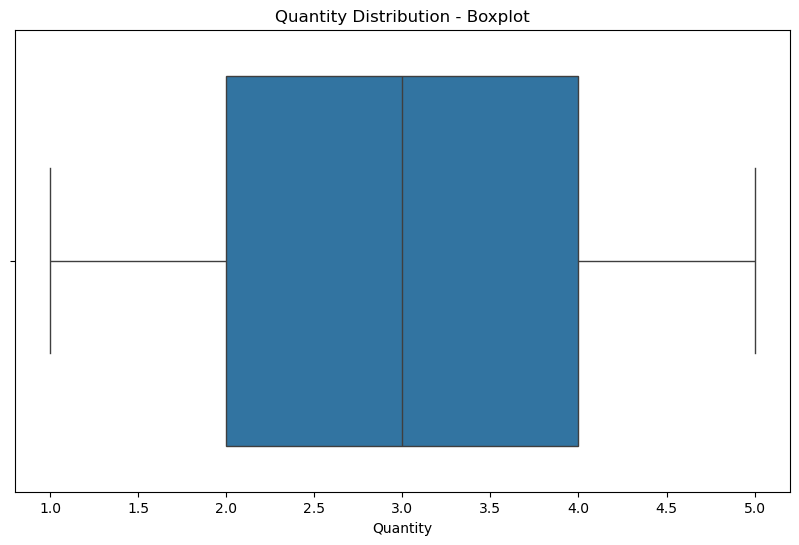

In [157]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "customer_shopping_data.csv"
shop = pd.read_csv(file_path)

numerical_columns = ['price', 'age', 'quantity']  

for column in numerical_columns:
    # Histogram
    plt.figure(figsize=(10, 6))
    plt.hist(shop[column], bins=20, edgecolor='black')
    plt.title(f'{column.capitalize()} Distribution')
    plt.xlabel(column.capitalize())
    plt.ylabel('Frequency')
    plt.show()

    # Boxplot
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=shop[column])
    plt.title(f'{column.capitalize()} Distribution - Boxplot')
    plt.xlabel(column.capitalize())
    plt.show()




I used this code to visualize numeric column distributions in the shop dataset and the possible presence of outliers. While histograms have given me a feeling for the distributions in general, boxplots gave me information about the central tendencies and the possible presence of outliers. These plots are interesting because they help one to get a rough idea about the structure of a dataset and other features of the dataset.

It is a histogram exhibiting the distribution of prices. Obviously, it is peaked among those close to 0 on the value scale, with many items. The frequency drops drastically as the price goes up, indicating that lower-priced items are very common.
This is a box plot of the price distribution. The majority of the prices focus in the lower part of the distribution, with very few high-magnitude prices clearly standing out as outliers. This translates into a high frequency of low-priced items and a low frequency of high-priced items in the dataset.

From this graph, we realize that the 20–70 ages are somewhat evenly distributed, with slightly larger density around the age of 20. This indicates that the customers fall along quite a wide span of ages.
Histograms and box plots of age and quantity distribution. The distribution of age contains sets of even 20-70 age groups. The quantity distribution generally remains focused on the amounts between 1 to 5, and there are no outliers. These plots describe pertinent information by visualizing the central tendencies and dispersion of data.

**Find and fix outliers**

Number of outliers in price: 5024


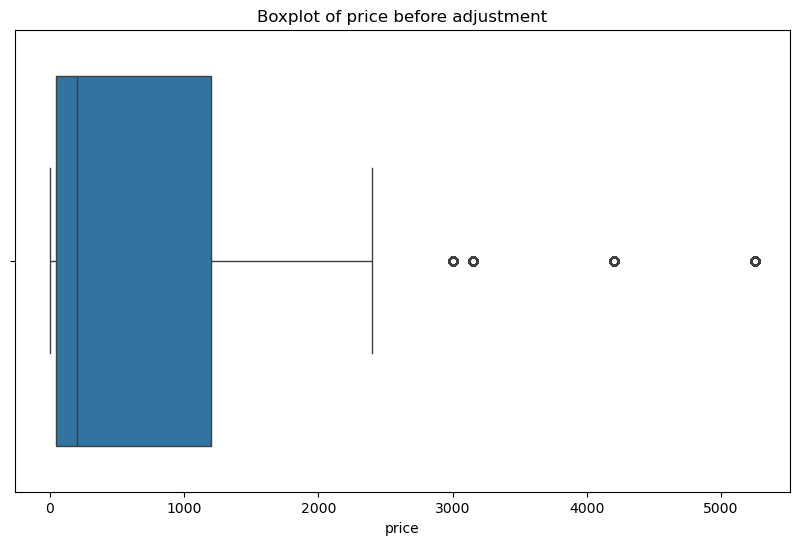

Outliers in price have been fixed.


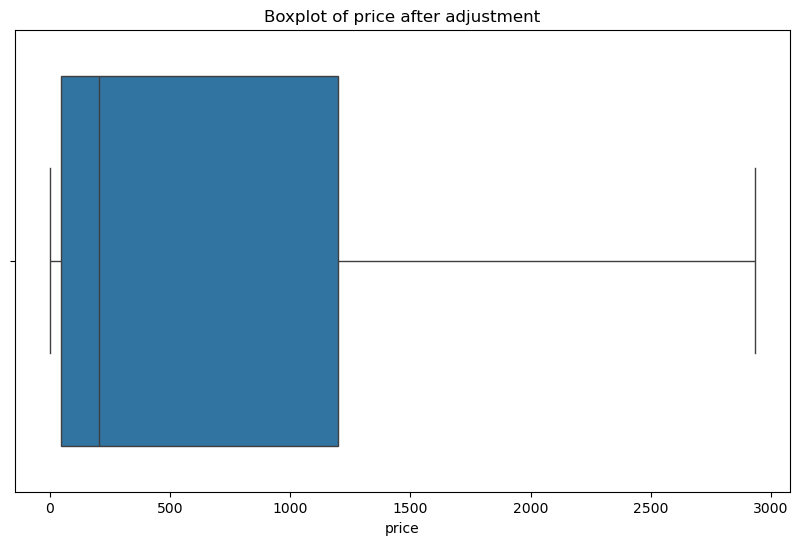

Number of outliers in age: 1


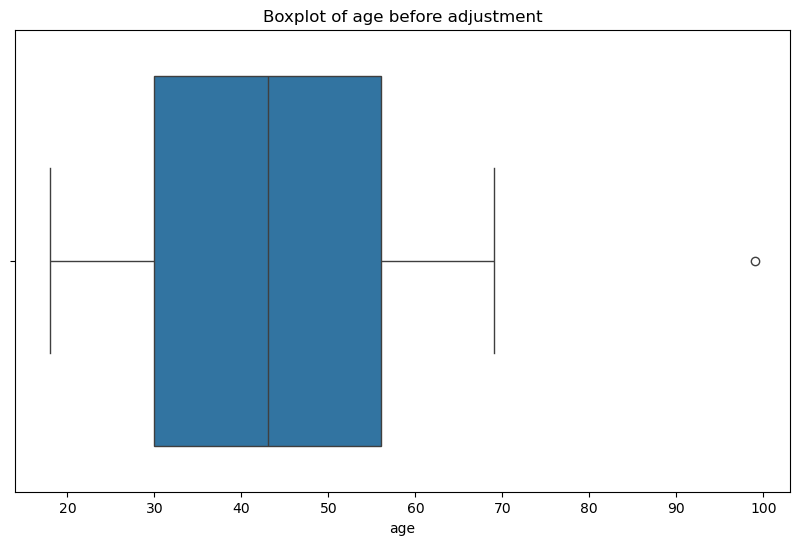

Outliers in age have been fixed.


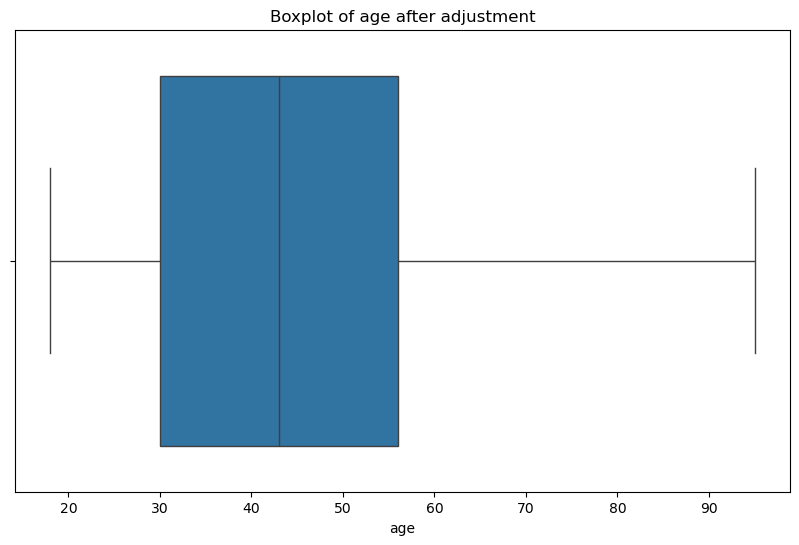

Number of outliers in quantity: 0


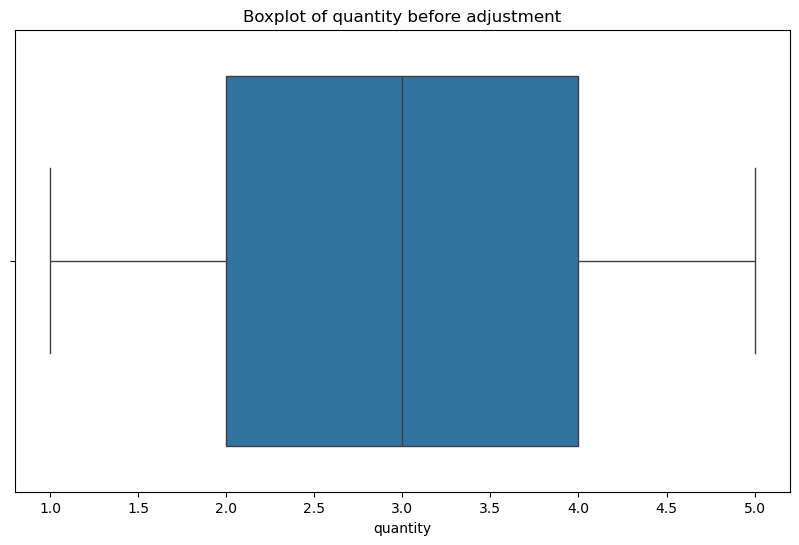

Outliers in quantity have been fixed.


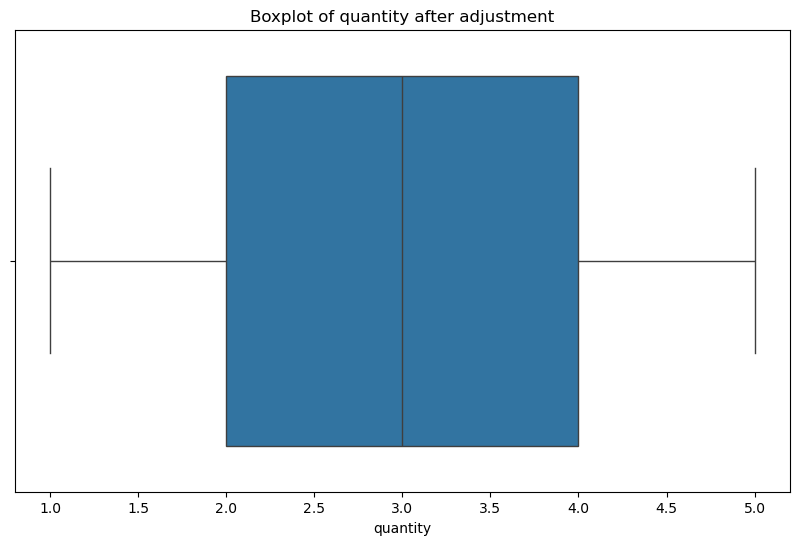

In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = "customer_shopping_data.csv"
shop = pd.read_csv(file_path)

# Function to detect and fix outliers
def detect_and_fix_outliers(shop, column):
    # Calculate relevant statistical metrics
    Q1 = shop[column].quantile(0.25)
    Q3 = shop[column].quantile(0.75)
    IQR = Q3 - Q1

    # Determine thresholds based on the calculated metrics
    lower_threshold = Q1 - 1.5 * IQR
    upper_threshold = Q3 + 1.5 * IQR

    # Identify the values that require attention
    outliers = shop[(shop[column] < lower_threshold) | (shop[column] > upper_threshold)]
    print(f"Number of outliers in {column}: {len(outliers)}")

    # Plot before adjustment
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=shop[column])
    plt.title(f'Boxplot of {column} before adjustment')
    plt.show()

    # Adjust values that exceed the thresholds
    shop.loc[shop[column] < lower_threshold, column] = lower_threshold
    shop.loc[shop[column] > upper_threshold, column] = upper_threshold
    print(f"Outliers in {column} have been fixed.")

    # Plot after adjustment
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=shop[column])
    plt.title(f'Boxplot of {column} after adjustment')
    plt.show()

# Apply the function to specific columns
target_columns = ['price', 'age', 'quantity']  # Adjust based on the columns you need

for column in target_columns:
    detect_and_fix_outliers(shop, column)


I used this code to detect and correct outliers in the columns price, age, and quantity of the shop dataset. After the identification of the outliers, I limited those values ​​to appropriate thresholds to make sure consistency in the dataset. I did a visualization also for the columns distributions before and after correcting the outliers, so that one can see the impact of the changes. This was done to make sure that extreme values ​​in the dataset did not hurt, too negatively, the accuracy of the analysis.

In [165]:
# Outlier Detection, Correction, and Data Export
import pandas as pd

# Load the dataset
file_path = "customer_shopping_data.csv"
shop = pd.read_csv(file_path)

# Function to detect and fix outliers
def detect_and_fix_outliers(shop, column):
    Q1 = shop[column].quantile(0.25)
    Q3 = shop[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_threshold = Q1 - 1.5 * IQR
    upper_threshold = Q3 + 1.5 * IQR

    # Identify the values that require attention
    outliers = shop[(shop[column] < lower_threshold) | (shop[column] > upper_threshold)]
    print(f"Number of outliers in {column}: {len(outliers)}")

    # Adjust values that exceed the thresholds
    shop.loc[shop[column] < lower_threshold, column] = lower_threshold
    shop.loc[shop[column] > upper_threshold, column] = upper_threshold
    print(f"Outliers in {column} have been fixed.")

# Apply the function to specific columns
target_columns = ['price', 'age']  # Quantity is not included as there are no outliers

for column in target_columns:
    detect_and_fix_outliers(shop, column)

# Save the cleaned data if needed
shop.to_csv("cleaned_customer_shopping_data.csv", index=False)

Number of outliers in price: 5024
Outliers in price have been fixed.
Number of outliers in age: 1
Outliers in age have been fixed.


I used this code to detect and correct outliers in price and age columns of the shop dataset. On detection of these outliers, I changed these values ​​to acceptable limits for the integrity of the dataset. In the meantime, after these operations, I saved this cleaned dataset as "cleaned_customer_shopping_data.csv". This way, I avoided a bad effect of outliers on data analysis and created a clean data set.

**Fix skewness if any**

Skewness of price: 2.247371459057575


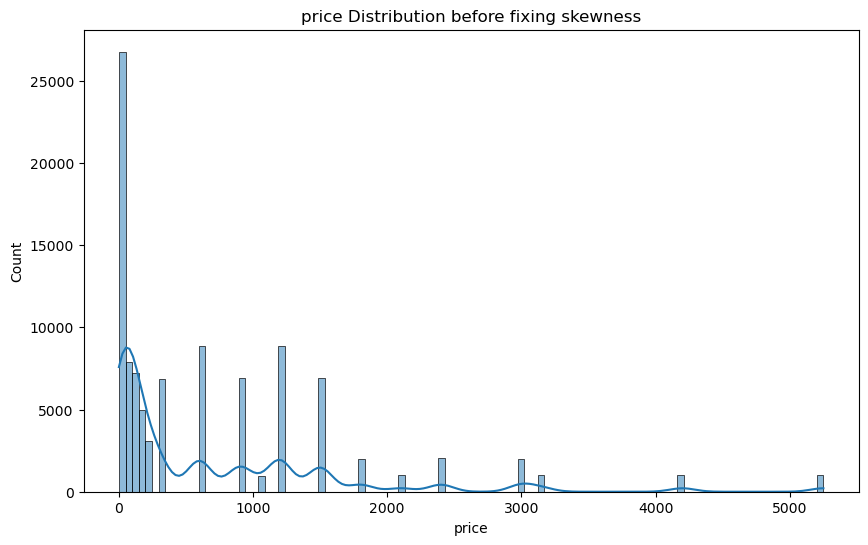

Applied log transformation to price


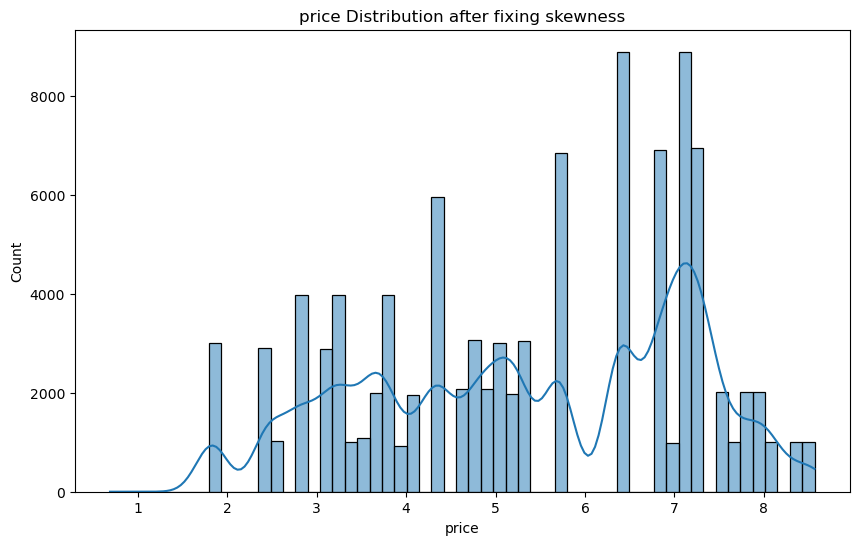

Skewness of age: 0.009394733254695382


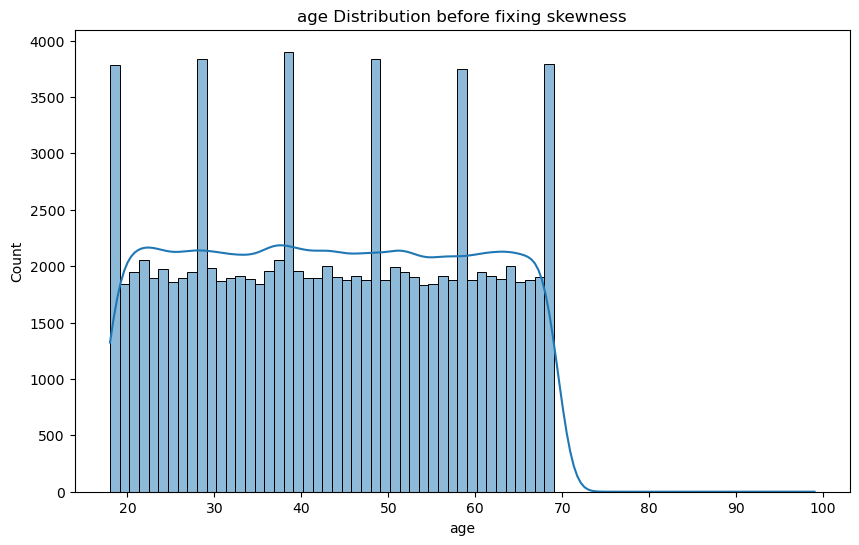

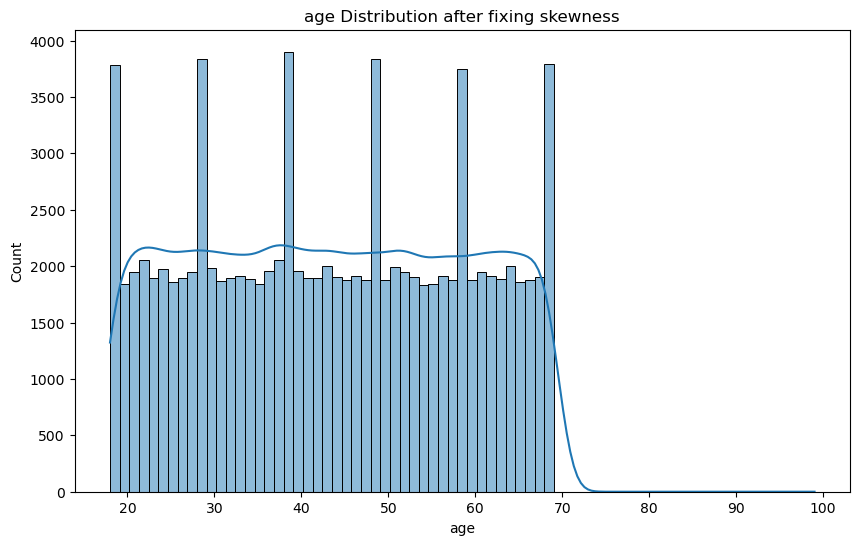

Skewness of quantity: -0.0012850421905017803


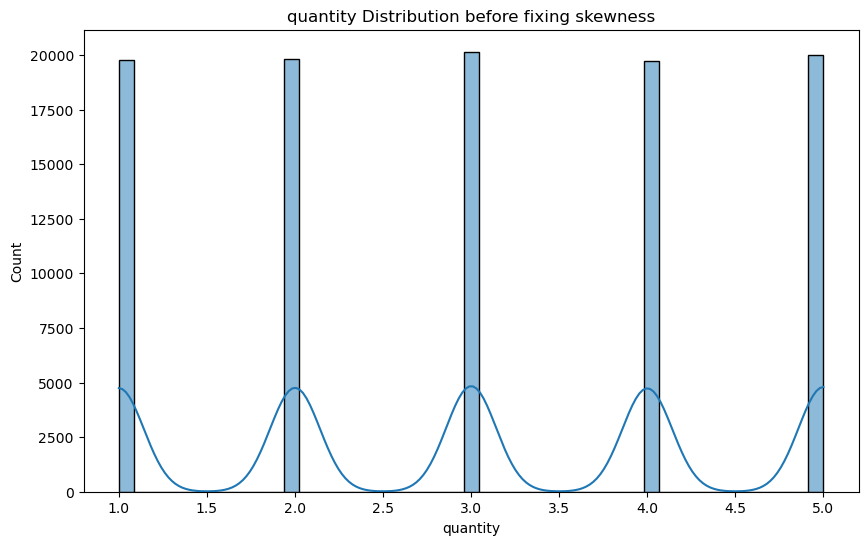

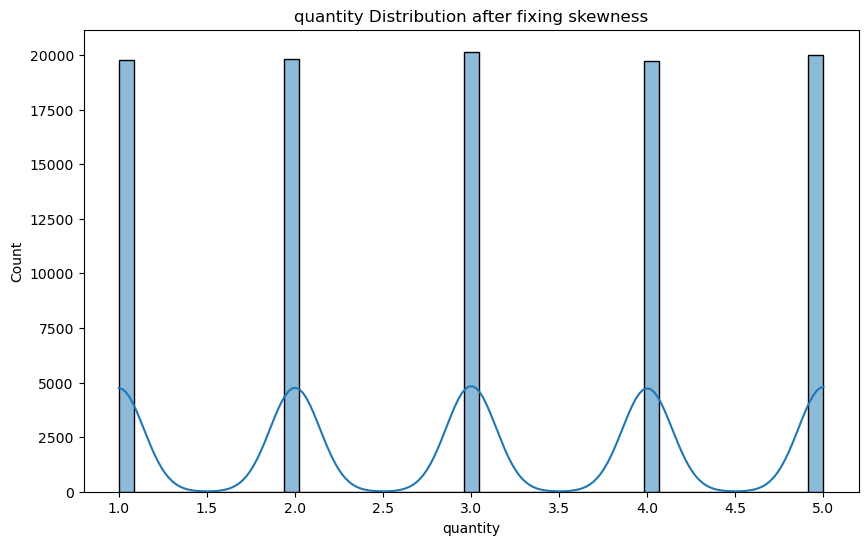

In [170]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = "customer_shopping_data.csv"
shop = pd.read_csv(file_path)

# Function to detect and fix skewness
def fix_skewness(shop, column):
    skewness = shop[column].skew()
    print(f'Skewness of {column}: {skewness}')

    # Plot before fixing skewness
    plt.figure(figsize=(10, 6))
    sns.histplot(shop[column], kde=True)
    plt.title(f'{column} Distribution before fixing skewness')
    plt.show()

    # Apply transformation based on skewness
    if skewness > 0.5:
        shop[column] = np.log1p(shop[column])  # Log transformation for positive skewness
        print(f'Applied log transformation to {column}')
    elif skewness < -0.5:
        shop[column] = np.square(shop[column])  # Square transformation for negative skewness
        print(f'Applied square transformation to {column}')

    # Plot after fixing skewness
    plt.figure(figsize=(10, 6))
    sns.histplot(shop[column], kde=True)
    plt.title(f'{column} Distribution after fixing skewness')
    plt.show()

# Apply the function to specific columns
target_columns = ['price', 'age', 'quantity']  # Adjust based on the columns you need

for column in target_columns:
    fix_skewness(shop, column)

# Save the cleaned data if needed
shop.to_csv("skewness_fixed_customer_shopping_data.csv", index=False)


I used this code for skewness detection and its correction in columns price, age, quantity of the shop dataset. First of all, the degree of skewness is computed for every column, then it is shown. Afterwards, I visualized column data distribution before skew correction using a histogram and KDE. As guided by the degree of skewness, I did a logarithm transformation on positive skewness and a square transformation on negative skewness. After that, I visualized again the distribution of the data, then examined the effect of the process. Finally, I saved the dataset with the corrected skewness. This would therefore correct the skew in the dataset, hence availing a more reliable and accurate analysis.

**Section 2: Analysis**



In this section, we will perform various analyses to understand customer behavior and spending patterns. The analyses will include:
1. Customer segmentation by category.
2. Spending distribution by gender (Box Plot).
3. Relationship between age and spending (Scatter Plot).














**Customer Segments / Categories**

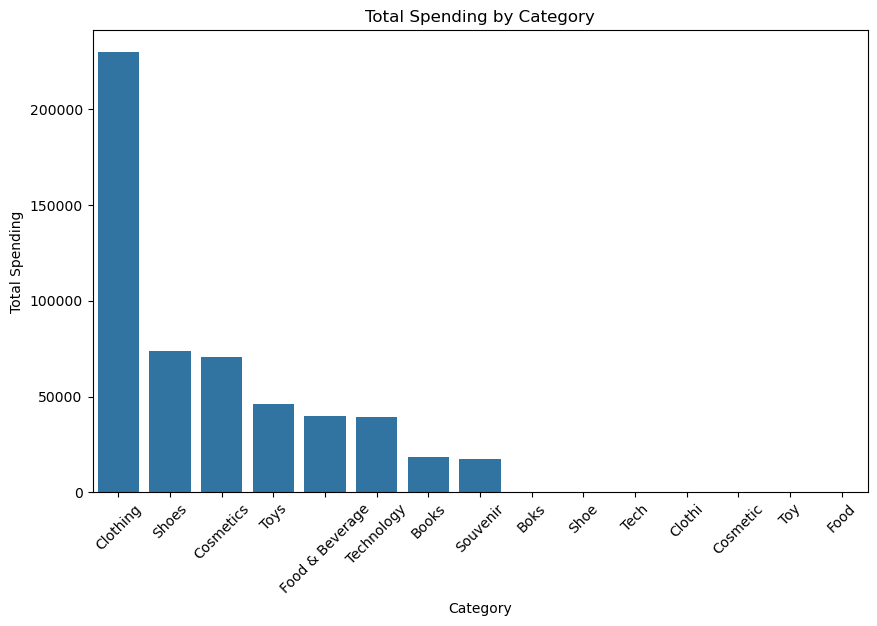

In [174]:
import seaborn as sns
import matplotlib.pyplot as plt

#Group category and sum the prices

category_spending = shop.groupby('category')['price'].sum().sort_values(ascending=False)

# Plot the spending by category
plt.figure(figsize=(10, 6))
sns.barplot(x=category_spending.index, y=category_spending.values)
plt.title('Total Spending by Category')
plt.xlabel('Category')
plt.ylabel('Total Spending')
plt.xticks(rotation=45)
plt.show()

I used this code to calculate and visualize, on the shop dataset, the total spend—price—grouped by the category column. In other words, I found the total spend by category and visualized these values ​​through a bar chart. On the horizontal axis, it contains the categories, while along the vertical, the total spend. This was done to understand which categories had the highest total spend.Clothing category is where customers spend the most. This shows that clothing is an important shopping item for customers.

**Spending Distribution by Gender**

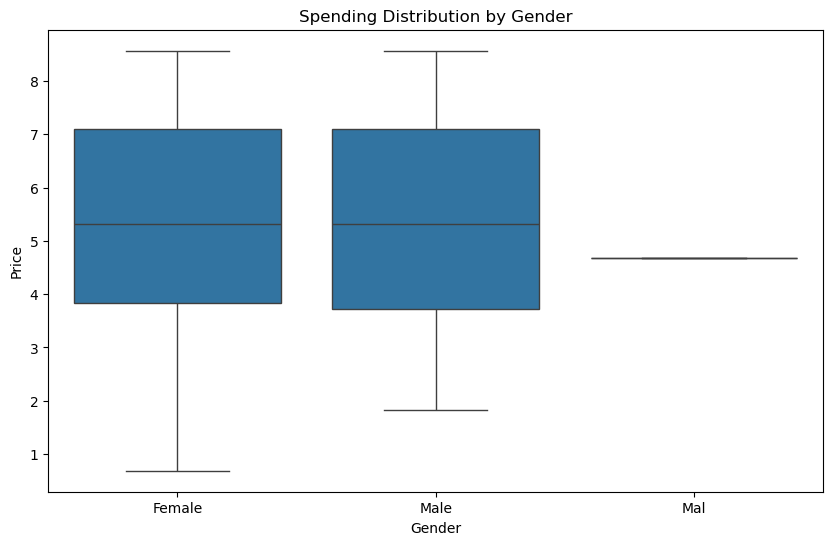

In [179]:
# Box plot for spending gender
plt.figure(figsize=(10, 6))
sns.boxplot(x='gender', y='price', data=shop)
plt.title('Spending Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Price')
plt.show()

I used this code to check the spending distribution—price by gender—in the shops dataset. I would use a box plot to represent the spending distribution in each gender group. This chart would let me know the mean, the median, and possible outliers for spending by gender. This was done to understand spending differences between genders.

The spending distribution of female and male customers seem quite similarly. There is no major difference in spending between the tow groups. 
Both genders have similar average spending.
There is some outliers in the graph, especially an outlier at lower limit for female customers.
The spending medians of female and male customers are quite close to each other.

**Relationship between age and spending (Scatter Plot)**

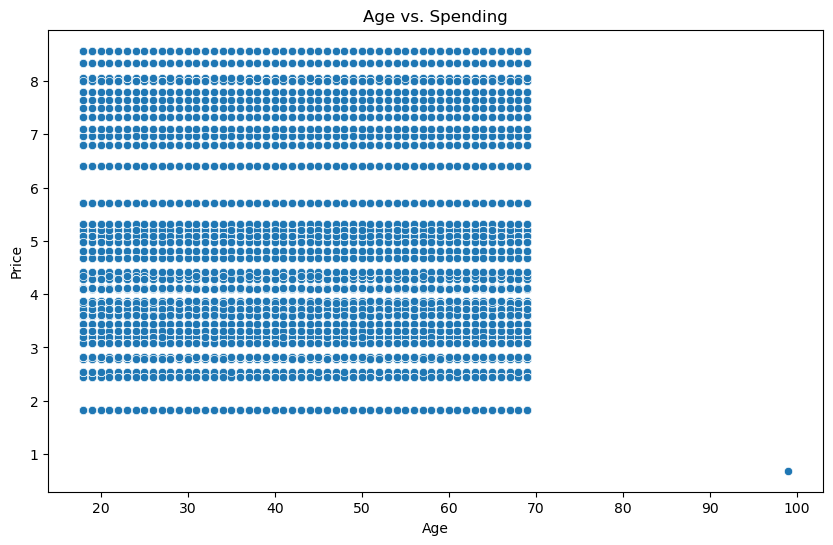

In [184]:
# Scatter plot for age vs. spending
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='price', data=shop)
plt.title('Age vs. Spending')
plt.xlabel('Age')
plt.ylabel('Price')
plt.show()

I used this code to examine the relationship of age and spend in the shop dataset. I created a scatter plot, where for each customer, it creates a point on the graph showing their age and their spend. This graph lets me see whether there is any relationship between age and spend.
This is a scatter plot for age versus spending. Each point represents the age of a customer and his or her spending. It is depicted that there is no general single direction wherein spending can be related to the age of the customer. This shows that no important or serious influence brought to bear by age on spending in general behavior.

**Section 3**

**Sales by Payment Method**

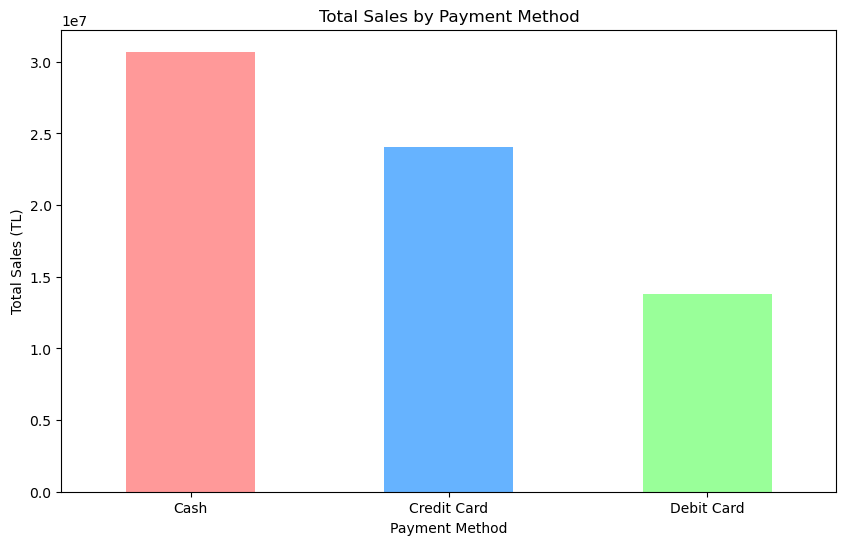

In [189]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = "customer_shopping_data.csv"
shop = pd.read_csv(file_path)

# Replace common errors or inconsistencies
shop['payment_method'] = shop['payment_method'].replace({
    'Cash Cash': 'Cash',
    'CreditCard': 'Credit Card',
    '##error##': 'Unknown'  # Replace with 'Unknown' or you can drop these rows if appropriate
})

# Drop rows where payment_method is still 'Unknown' if that's the right decision for your analysis
shop = shop[shop['payment_method'] != 'Unknown']

# Group by payment method and sum the prices
payment_sales = shop.groupby('payment_method')['price'].sum()

# Plot the total sales by payment method
plt.figure(figsize=(10, 6))
payment_sales.plot(kind='bar', color=['#ff9999','#66b3ff','#99ff99'])
plt.title('Total Sales by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales (TL)')
plt.xticks(rotation=0)
plt.show()

I used this code to correct common errors or inconsistencies in the column of the payment method, then used it to plot total sales by payment method for the shop dataset.

First, I replaced the wrong or inconsistent values ​​with the correct values. Then, removed the rows of datasets containing 'Unknown'. Again, I got the total sales by payment method and drew them by the bar chart.

**Sales Trend Over Time**

16 dates could not be converted.


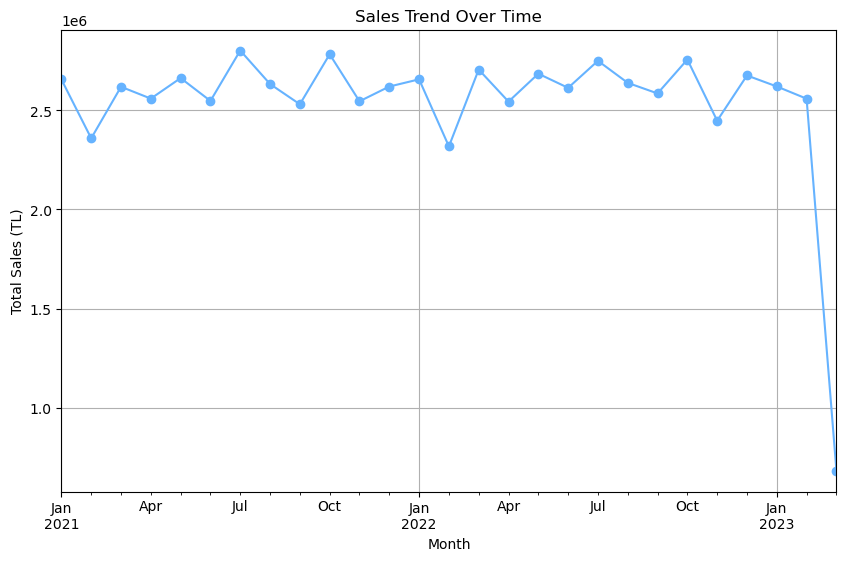

In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
file_path = "customer_shopping_data.csv"
shop = pd.read_csv(file_path)

# Function to handle different date formats
def convert_date(x):
    try:
        # Convert serial numbers (like Excel dates) to datetime
        if isinstance(x, (int, float)) and len(str(int(x))) == 5:
            return pd.to_datetime('1899-12-30') + pd.to_timedelta(int(x), unit='D')
        else:
            # Try converting strings to datetime
            return pd.to_datetime(x, errors='coerce')
    except:
        return pd.NaT  # Return NaT (Not a Time) if conversion fails

# Apply the function to convert the 'invoice_date' column
shop['invoice_date'] = shop['invoice_date'].apply(convert_date)

# Check for any remaining non-datetime values or NaT values
print(shop['invoice_date'].isna().sum(), "dates could not be converted.")

# Drop rows with invalid dates if necessary
shop = shop.dropna(subset=['invoice_date'])

# Group by month and sum the prices
monthly_sales = shop.groupby(shop['invoice_date'].dt.to_period('M'))['price'].sum()

# Plot the sales trend over time
plt.figure(figsize=(10, 6))
monthly_sales.plot(kind='line', marker='o', color='#66b3ff')
plt.title('Sales Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales (TL)')
plt.grid(True)
plt.show()

I used this code to transform dates given in different formats within the column 'invoice_date' of the 'shop' dataset into a standard datetime format, clean up incorrect/invalid dates, and then conduct time series analysis in order to visualize monthly sales trends.

First, I converted these values ​​into datetime format, considering that the date column can be either serial numbers (like Excel dates) or text dates. Then, I masked the invalid dates as NaT (Not a Time) and removed rows having NaT from the dataset. Later on, I will calculate total sales for every month and visualize these sales trends by a line chart.

This time series chart indicates that total monthly sales fluctuated between the years 2021 and 2023. In general, sales follow a smooth course with sharp drops and increases during certain periods. There is a huge drop towards 2023, likely due to lack of data or any other cause.

### **Recommandation**

In the light of this analysis on customers' shopping data, several strategic recommendations can be implemented to improve sales and loyalty. First of all, high purchase frequency is noted in the younger age group. The company can take advantage of this by bringing onboard the right marketing campaigns aimed at this particular age group. For example, promotions of trendy fashion items, cosmetics, and personalized shopping experiences can go a long way in boosting engagement and sales. It also indicates a strong bias toward credit card transactions. In order to enhance the satisfaction of customers, the company is required to make the process of checkout easy fast, convenient, and secure which would also contribute to reducing the cart abandonment rate. Further, time-series analysis of the sales trend indicates periods of low activity. The company should therefore have targeted seasonal promotions or discounts during such seasons to keep the revenue stream flowing. Looking at such fluctuations can help the company avoid tenuous drops in sales. Enhancing customer loyalty programs with special rewards, personalized discounts, and incentives for repeat purchases will finally cement long-term relationships and drive continuous revenue growth.